# Shapes demo

A picture-based hello-world with **no downloads and no backbone**:
half the images hold a bright circle, half are empty, and the black box
answers "circle or not". A good explanation paints the circle red
(evidence toward the answer) and the background blue or blank.

Everything runs on CPU in a few seconds.

In [1]:
import numpy as np
import torch

rng = np.random.RandomState(0)

n, height, width = 200, 32, 32
x = np.zeros((n, 1, height, width), dtype=np.float32)
y_outputs = np.zeros(n, dtype=np.int64)
rows, cols = np.ogrid[:height, :width]
for i in range(n):
    if rng.rand() < 0.5:
        cy, cx, r = rng.randint(8, 24), rng.randint(8, 24), rng.randint(5, 8)
        x[i, 0][(rows - cy) ** 2 + (cols - cx) ** 2 <= r * r] = 1.0
        y_outputs[i] = 1
print(x.shape, y_outputs.mean())  # (200, 1, 32, 32), ~half circles

(200, 1, 32, 32) 0.41


In [2]:
import ruleofthumb as rot

exp = rot.fit_image(y_outputs=y_outputs, x_inputs=x, epochs=30, batch_size=64, learning_rate=0.01, seed=0)

In [3]:
preds = exp.predict(torch.from_numpy(x)).cpu().numpy()
print(f"surrogate accuracy vs black-box labels: {(preds == y_outputs).mean():.2f}")

surrogate accuracy vs black-box labels: 1.00


## Where the model looks

`get_explanation` returns one signed number per pixel: positive (red)
pushed toward the predicted answer, negative (blue) pushed away.

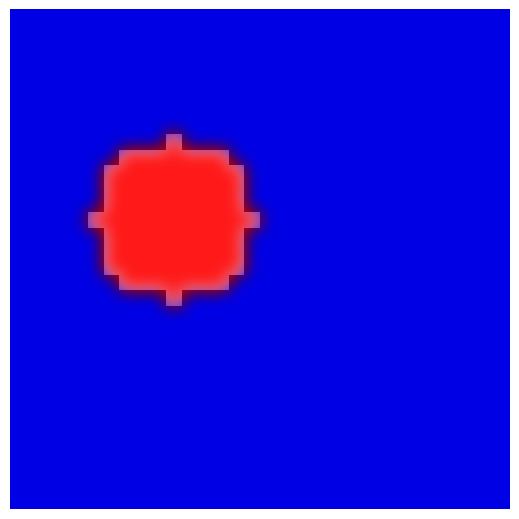

In [4]:
from ruleofthumb import plot

which = int(np.flatnonzero(y_outputs == 1)[0])  # a circle image
imp = exp.get_explanation(x[which : which + 1])[0]  # [H, W]
grey = np.repeat(x[which].transpose(1, 2, 0), 3, axis=2)
fig = plot.saliency(imp, image=grey)

## The payoff: fewer pixels, same answer

Reveal pixels most-important-first and re-check the answer at each
step. The learned order keeps the right answer after a few pixels;
a random order needs most of the image.

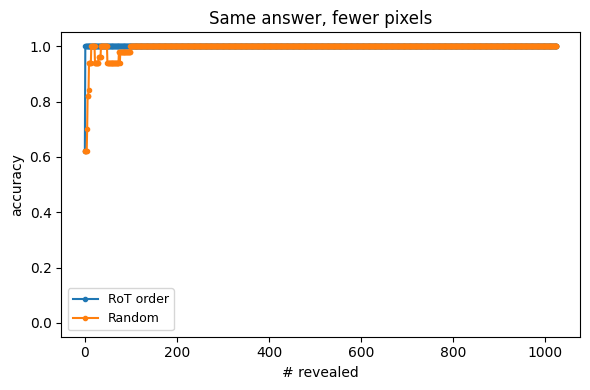

In [5]:
sample = 50
points = torch.from_numpy(x[:sample])
labels = torch.from_numpy(y_outputs[:sample])
order = exp.get_order(points)
good = exp.score_ordering(points, labels, order)
random_order = np.tile(rng.permutation(height * width), (sample, 1)).reshape(sample, height, width)
random = exp.score_ordering(points, labels, random_order)
fig = plot.reveal({"RoT order": good, "Random": random}, title="Same answer, fewer pixels")